# Understanding SteelMPF parameters

Before calibrating, it helps to see **what each SteelMPF parameter does** on a fixed
brace geometry and displacement history.

In this notebook you will:
- pick a base SteelMPF vector (sensible defaults — not all `a1`–`a4` equal to 1)
- choose a displacement history: synthetic growing cycles, or a real specimen record
- vary **one parameter at a time** and overlay the resulting hysteresis

No optimizer runs here. Simulation uses the same corotational BRB + SteelMPF path
as calibration (`simulate_force_disp` in `scripts/examples/notebook_support.py`).

Edit **Parameters**, then run the cells below in order.


## Browse the specimen catalog

Before you pick a specimen name, look at what is in the repo:

- a **table** from `config/calibration/BRB-Specimens.csv` (geometry + layout flags)
- a **grid of raw hysteresis** from `data/raw/{Name}/` (unfiltered)

Path-ordered tests draw as loops; digitized tests draw as points.
Then edit **Parameters** below and choose a `Name` you like.


,Name,experimental_layout,path_ordered,fyp,A_sc,A_t,L_T,L_y,individual_optimize,generalized_weight
0,PC250,raw,true,41.30,5.96,59.60,251.96,179.40,true,1
1,PC350,raw,true,41.30,8.34,83.40,252.02,183.30,true,1
2,PC160,raw,true,41.30,3.80,38.00,252.00,176.00,true,1
3,PC500,raw,true,37.90,12.66,126.60,251.98,185.10,true,1
4,PC750A,raw,true,37.90,17.85,178.50,251.98,184.20,true,1
5,PC750B,raw,true,37.90,17.87,178.70,251.96,179.40,true,1
6,PC1200A,raw,true,37.90,28.53,285.30,252.02,185.20,true,1
7,PC1200B,raw,true,37.90,28.62,286.20,251.96,181.30,true,1
8,PC3SB,digitized,true,40.00,5.00,50.00,116.00,78.00,true,0
9,A5,digitized,false,44.08,5.66,56.60,215.55,148.70,false,0


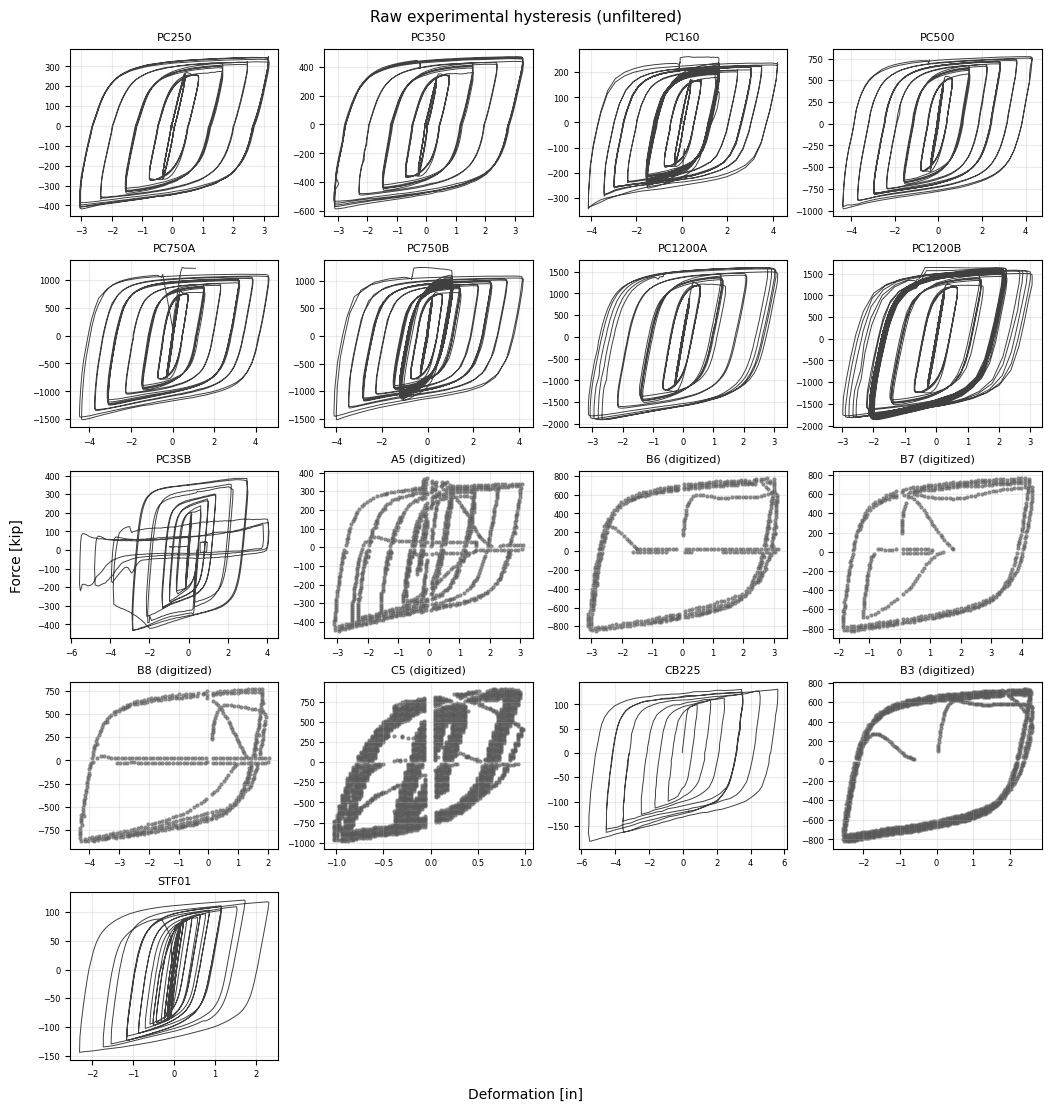

catalog rows: 17


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import show_specimen_catalog  # noqa: E402

catalog = show_specimen_catalog()
print("catalog rows:", len(catalog))


## Parameter roles (SteelMPF)

OpenSees syntax (see also `scripts/examples/simple_brb_steelmpf.py`):

`uniaxialMaterial SteelMPF $mattag $fyp $fyn $E0 $bp $bn $R0 $cR1 $cR2 <$a1 $a2 $a3 $a4>`

Descriptions below follow this repo’s write-up (`docs/BRB Calibration using SteelMPF.pdf`
and `paper/main.tex`). The OpenSees wiki text for `a1`–`a4` / `cR*` is easy to misread:
it sometimes swaps tension vs compression wording and reuses the labels `a1`/`a2` for the
recommended `cR1`/`cR2` values.

| Parameter | Role |
|-----------|------|
| `fyp`, `fyn` | Yield strength in tension (+) / compression (−) [ksi] |
| `E` | Initial modulus [ksi] (brace model uses `E_hat = Q E`) |
| `b_p`, `b_n` | Strain-hardening ratio in tension / compression |
| `R0` | Initial curvature of the elastic ↔ post-yield transition (Bauschinger rounding; ≈20 typical) |
| `cR1`, `cR2` | How that transition curvature `R` degrades with plastic excursion (≈0.925 and ≈0.15 typical) |
| `a1` | **Compression** isotropic shift scale: shifts the compression yield envelope by a proportion of `fyn` |
| `a2` | Compression isotropic threshold: shift activates after a max plastic **tensile** strain of about `a2 · fyp / E_hat` |
| `a3` | **Tension** isotropic shift scale: shifts the tension yield envelope by a proportion of `fyp` |
| `a4` | Tension isotropic threshold: shift activates after a max plastic **compressive** strain of about `a4 · fyn / E_hat` |

In equations (paper): tension isotropic uses `(a3, a4)`; compression isotropic uses `(a1, a2)`.
Keep `a2` and `a4` near 1 and put the interesting values in `a1` / `a3`. Setting all four to 1
(or all to 0) makes the isotropic terms idle or degenerate, so one-at-a-time plots look flat.


## Parameters

`BASE` is geometry + SteelMPF. `SWEEPS` lists alternate values for each free
parameter (base value is always plotted too). `DISPLACEMENT_HISTORY` is
`"synthetic"` or a specimen `Name` with resampled data.


In [2]:
from pathlib import Path
import sys

# --- edit these ---
SPECIMEN_GEOMETRY = "PC160"  # catalog geometry / fy
DISPLACEMENT_HISTORY = "synthetic"  # "synthetic" or a Name with data/resampled/{Name}/...

# Growing-cycle synthetic protocol [in] (ignored when DISPLACEMENT_HISTORY is a specimen Name)
SYNTHETIC_AMPS = [0.4, 0.8, 1.6, 2.4, 3.2]
SYNTHETIC_N_QUARTER = 35

BASE_STEEL = {
    "b_p": 0.01,
    "b_n": 0.025,
    "R0": 20.0,
    "cR1": 0.925,
    "cR2": 0.15,
    # Isotropic: a1/a2 = compression, a3/a4 = tension (a2=a4=1 keeps a1/a3 active).
    "a1": 0.04,
    "a2": 1.0,
    "a3": 0.04,
    "a4": 1.0,
}

# One-at-a-time values (base is overlaid automatically)
SWEEPS = {
    "b_p": [0.002, 0.01, 0.04],
    "b_n": [0.005, 0.025, 0.06],
    "R0": [10.0, 20.0, 40.0],
    "cR1": [0.7, 0.925, 0.98],
    "cR2": [0.05, 0.15, 0.3],
    "a1": [0.0, 0.04, 0.12],
    "a3": [0.0, 0.04, 0.12],
    "a2": [0.5, 1.0, 2.0],
    "a4": [0.5, 1.0, 2.0],
}

NORMALIZED = True
# ------------------

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import (  # noqa: E402
    geometry_from_catalog,
    load_experiment_force_disp,
    make_cyclic_drive,
    plot_steelmpf_param_sweep,
    simulate_force_disp,
)
print("repo:", ROOT)
print("geometry:", SPECIMEN_GEOMETRY)
print("displacement history:", DISPLACEMENT_HISTORY)


repo: C:\Users\garaujor\source\repos\BRB-Calibration
geometry: PC160
displacement history: synthetic


## Build displacement history + base response

Uses catalog geometry for `SPECIMEN_GEOMETRY`. A synthetic history is fast and easy to
read; a real Name uses that specimen's resampled deformation history.


displacement history='synthetic'  n=701
BASE: {'b_p': 0.01, 'b_n': 0.025, 'R0': 20.0, 'cR1': 0.925, 'cR2': 0.15, 'a1': 0.04, 'a2': 1.0, 'a3': 0.04, 'a4': 1.0}


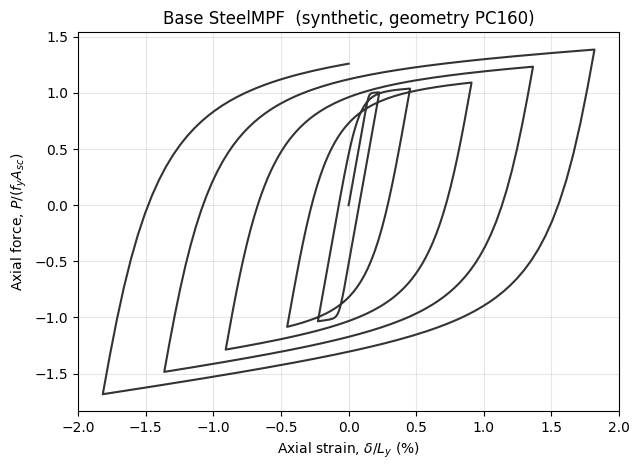

In [3]:
import matplotlib.pyplot as plt

geom = geometry_from_catalog(SPECIMEN_GEOMETRY, E=29000.0)
BASE = {**geom, **BASE_STEEL}

if str(DISPLACEMENT_HISTORY).strip().lower() == "synthetic":
    disp = make_cyclic_drive(SYNTHETIC_AMPS, n_quarter=SYNTHETIC_N_QUARTER)
    history_label = "synthetic"
else:
    disp, _exp_force = load_experiment_force_disp(str(DISPLACEMENT_HISTORY))
    history_label = str(DISPLACEMENT_HISTORY)

print(f"displacement history={history_label!r}  n={len(disp)}")
print("BASE:", {k: BASE[k] for k in ("b_p", "b_n", "R0", "cR1", "cR2", "a1", "a2", "a3", "a4")})

# Reference hysteresis at BASE
_, F_base = simulate_force_disp(disp, **BASE)
fyA = BASE["fyp"] * BASE["A_sc"]
plt.figure(figsize=(6.5, 4.8))
if NORMALIZED:
    plt.plot(100.0 * disp / BASE["L_y"], F_base / fyA, color="0.2")
    plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
    plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
else:
    plt.plot(disp, F_base, color="0.2")
    plt.xlabel("Deformation [in]")
    plt.ylabel("Force [kip]")
plt.title(f"Base SteelMPF  ({history_label}, geometry {SPECIMEN_GEOMETRY})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## One-at-a-time sweeps

Each figure keeps every other parameter at `BASE` and overlays the listed values
of one parameter. Look for slope changes (`b_*`), changes in the transition from the
elastic to the post-yield asymptotes / Bauschinger rounding (`R0`/`cR*`), and loop
“inflation” / ratcheting from isotropic terms (`a*`).

Plot helper: `plot_steelmpf_param_sweep` in `scripts/examples/notebook_support.py`.


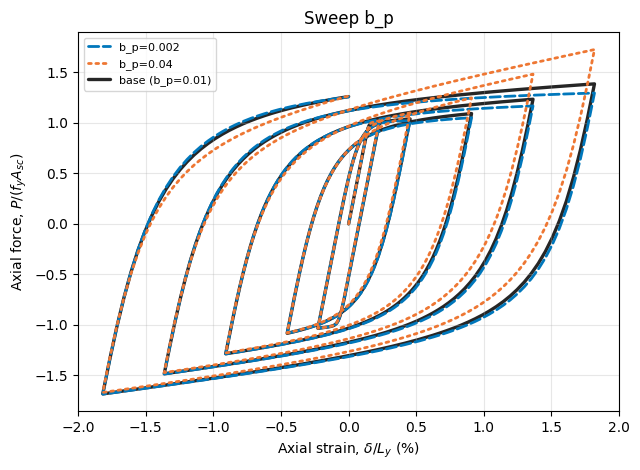

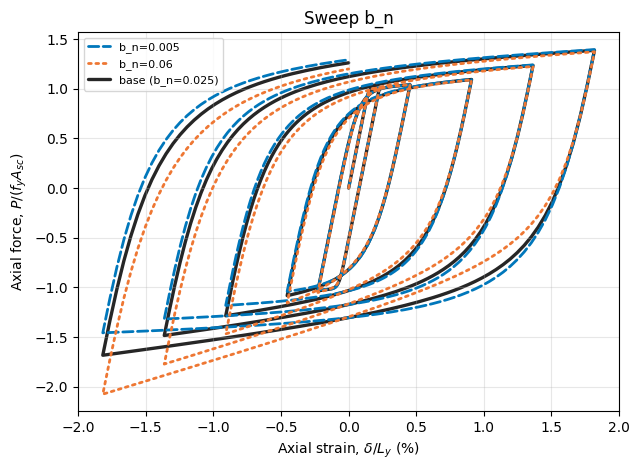

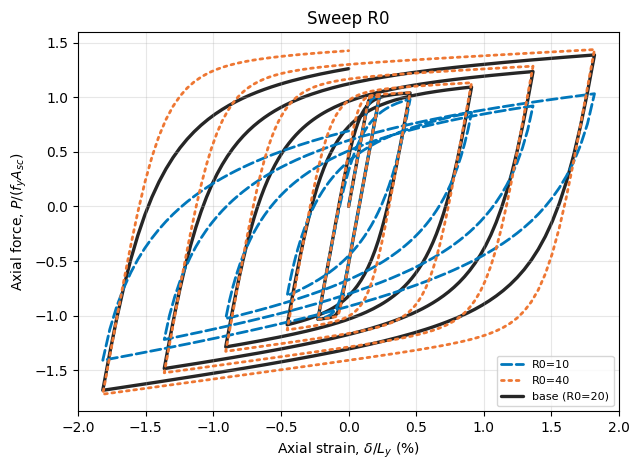

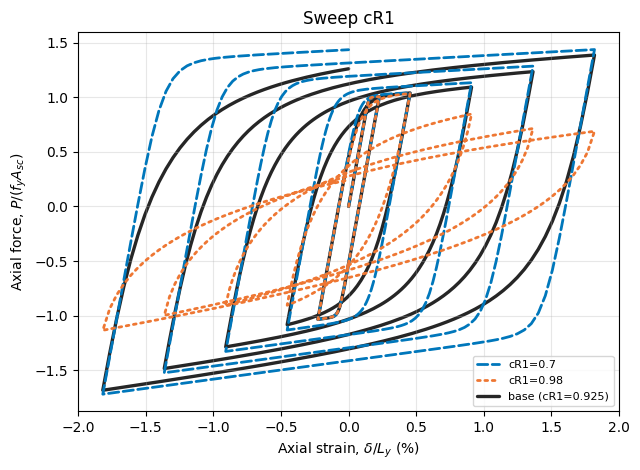

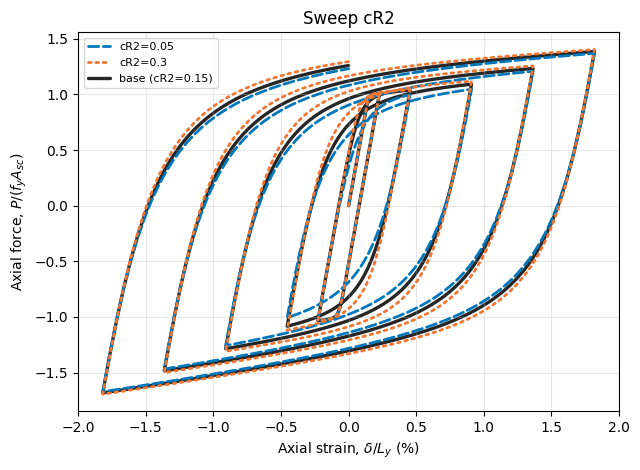

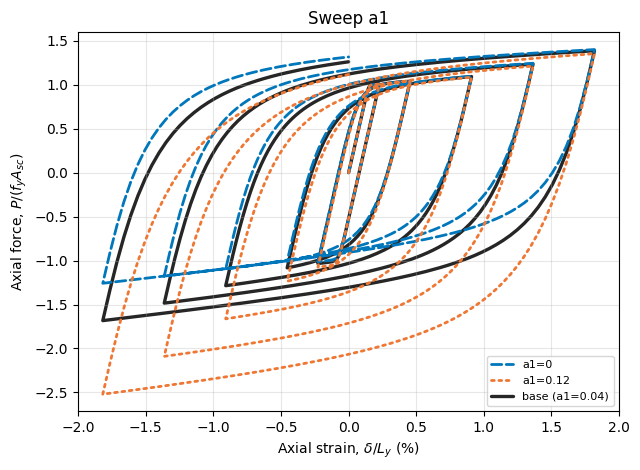

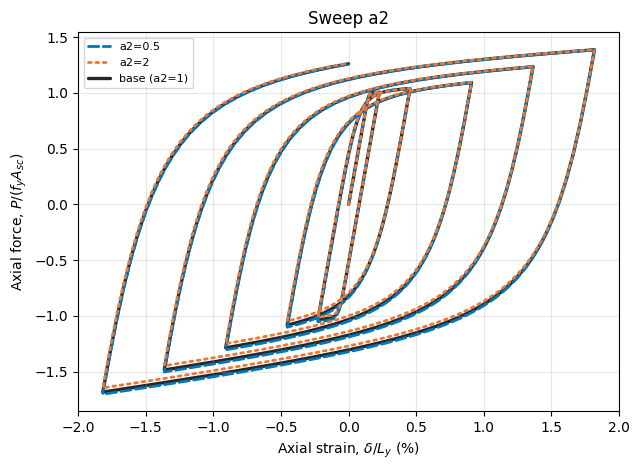

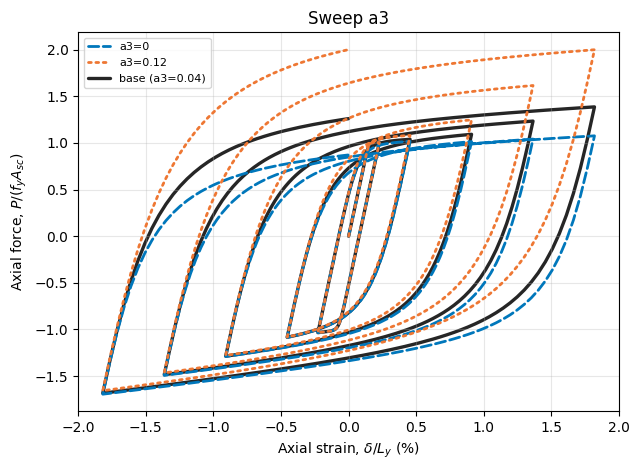

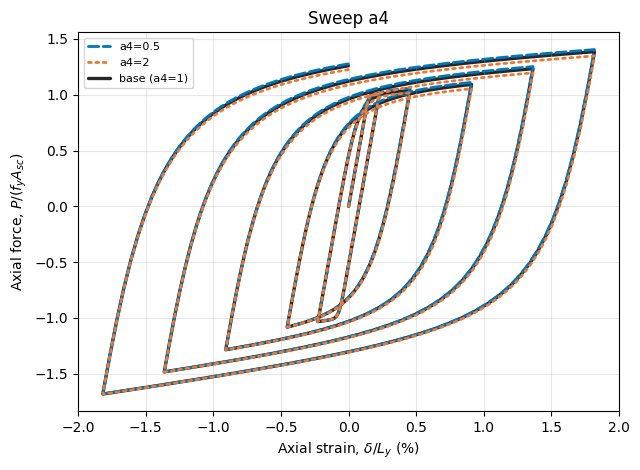

In [4]:
# Hardening ratios
for name in ("b_p", "b_n"):
    plot_steelmpf_param_sweep(
        disp, BASE, name, SWEEPS[name], normalized=NORMALIZED, title=f"Sweep {name}"
    )

# Transition elastic <-> post-yield asymptotes (Bauschinger rounding)
for name in ("R0", "cR1", "cR2"):
    plot_steelmpf_param_sweep(
        disp, BASE, name, SWEEPS[name], normalized=NORMALIZED, title=f"Sweep {name}"
    )

# Isotropic hardening (compression a1/a2, tension a3/a4)
for name in ("a1", "a2", "a3", "a4"):
    plot_steelmpf_param_sweep(
        disp, BASE, name, SWEEPS[name], normalized=NORMALIZED, title=f"Sweep {name}"
    )
